In [10]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import train_test_split
import json

In [2]:
root_dir = Path.cwd().parent
raw_dir = root_dir / "data" / "raw"
df = pd.read_csv(raw_dir / "WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df = df.drop("customerID", axis=1)

In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [5]:
df.isna().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [6]:
df = df.dropna()

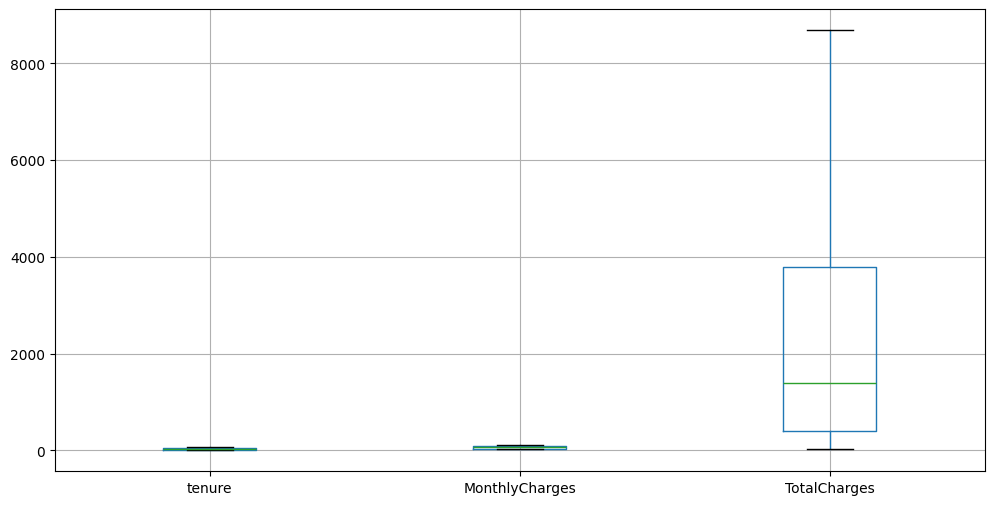

In [7]:
num_columns = df.select_dtypes(include='number').columns
num_columns = num_columns.drop("SeniorCitizen")
df[num_columns].boxplot(figsize=(12, 6))
plt.show()

In [8]:
X = df.drop("Churn", axis=1)
Y = df["Churn"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
trainset = pd.concat([X_train, Y_train], axis=1)
testset = pd.concat([X_test, Y_test], axis=1)

versions = set([v.name for v in Path(root_dir / "data"/"processed").iterdir() if re.match(r"v\d+", v.name)])
if versions:
    latest_version = versions[-1]
    new_version = f"v{int(latest_version[1:]) + 1}"
else:
    new_version = "v1"

processed_dir = root_dir / "data" / "processed" / new_version
processed_dir.mkdir(parents=True, exist_ok=True)

trainset.to_csv(processed_dir / "train.csv", index=False)
testset.to_csv(processed_dir / "test.csv", index=False)

In [12]:
cat_columns = X.columns.drop(num_columns)
schema = {
    "features" : {
        "numerical": num_columns.tolist(),
        "categorical": cat_columns.tolist()
    },
    "target": ["Churn"],
    "feature_engineering": {
        "numerical": {
        "scaler": "StandardScaler"
        },
        "categorical": {
        "encoding": "OneHotEncoder",
        "handle_unknown": "ignore"
        }
    }
}
json.dump(schema, open(processed_dir / "schema.json", "w"), indent=4)